In [2]:
import pandas as pd
import numpy as np

# Recreate raw data
np.random.seed(42)
n = 303

data = {
    'age': np.random.randint(29, 77, n),
    'sex': np.random.choice([0, 1], n, p=[0.32, 0.68]),
    'cp': np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08]),
    'trestbps': np.random.normal(131, 17, n).astype(int).astype(float),
    'chol': np.random.normal(246, 51, n).astype(int).astype(float),
    'fbs': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'restecg': np.random.choice([0,1,2], n, p=[0.50,0.48,0.02]),
    'thalach': np.random.normal(149, 22, n).astype(int).astype(float),
    'exang': np.random.choice([0, 1], n, p=[0.67, 0.33]),
    'oldpeak': np.round(np.random.exponential(1.0, n), 1),
    'slope': np.random.choice([0,1,2], n, p=[0.21,0.46,0.33]),
    'ca': np.random.choice([0,1,2,3], n, p=[0.58,0.22,0.13,0.07]).astype(float),
    'thal': np.random.choice([0,1,2,3], n, p=[0.01,0.06,0.72,0.21]).astype(float),
    'target': np.random.choice([0, 1], n, p=[0.46, 0.54])
}

df = pd.DataFrame(data)

# Clean it
df = df.drop_duplicates()
for col in ['trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']:
    df[col].fillna(df[col].median(), inplace=True)
df.loc[df['chol'] > 500, 'chol'] = df['chol'].median()
df.loc[df['chol'] <= 0, 'chol'] = df['chol'].median()
df.loc[df['trestbps'] > 200, 'trestbps'] = df['trestbps'].median()
df.loc[df['trestbps'] <= 0, 'trestbps'] = df['trestbps'].median()
df.loc[df['thalach'] > 200, 'thalach'] = df['thalach'].median()
df.loc[df['thalach'] < 60, 'thalach'] = df['thalach'].median()

df.to_csv('heart_disease_clean.csv', index=False)
print("✅ File recreated! Shape:", df.shape)

✅ File recreated! Shape: (303, 14)


/tmp/ipykernel_2759/108209634.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [3]:
df = pd.read_csv('heart_disease_clean.csv')
print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,0,128.0,220.0,0,0,173.0,1,2.9,0,0.0,2.0,1
1,57,0,0,123.0,193.0,1,1,146.0,1,2.2,0,0.0,2.0,0
2,43,1,2,113.0,282.0,0,1,101.0,0,0.5,1,0.0,1.0,0
3,71,0,3,102.0,258.0,0,1,167.0,1,1.5,2,0.0,3.0,0
4,36,1,0,144.0,217.0,0,0,137.0,0,0.6,2,0.0,3.0,1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_curve, auc, classification_report)

# Load cleaned data
df = pd.read_csv('heart_disease_clean.csv')
print("Shape:", df.shape)
df.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,0,128.0,220.0,0,0,173.0,1,2.9,0,0.0,2.0,1
1,57,0,0,123.0,193.0,1,1,146.0,1,2.2,0,0.0,2.0,0
2,43,1,2,113.0,282.0,0,1,101.0,0,0.5,1,0.0,1.0,0
3,71,0,3,102.0,258.0,0,1,167.0,1,1.5,2,0.0,3.0,0
4,36,1,0,144.0,217.0,0,0,137.0,0,0.6,2,0.0,3.0,1


In [6]:
# X = features, y = target (0 or 1)
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target values:", y.value_counts())

Features shape: (303, 13)
Target values: target
1    163
0    140
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [9]:
# Model 1 - Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Model 2 - Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Model 3 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("All 3 models trained!")

All 3 models trained!


In [10]:
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf
}

print("Model Accuracy Scores:")
print("-" * 35)
for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc*100:.2f}%")

Model Accuracy Scores:
-----------------------------------
Logistic Regression: 52.46%
Decision Tree: 55.74%
Random Forest: 60.66%


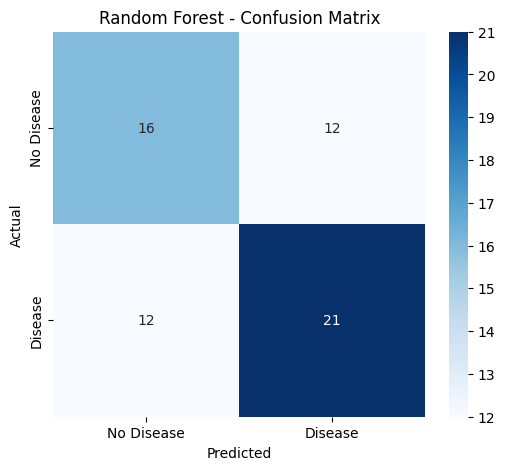

In [11]:
# Using Random Forest
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

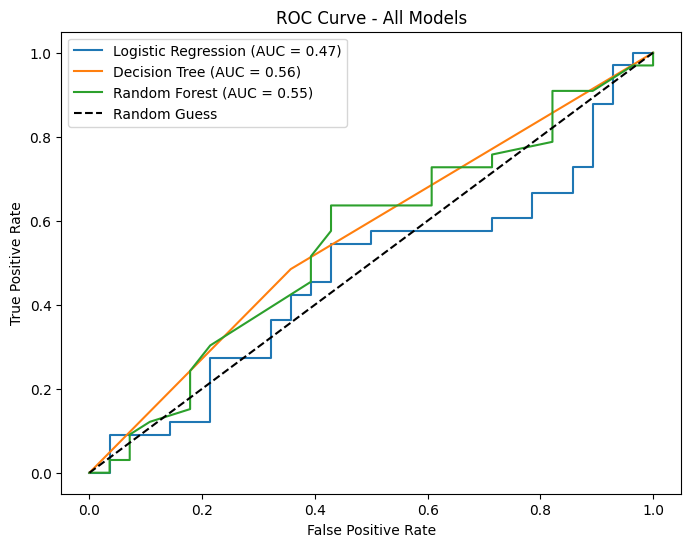

In [12]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()